In [1]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator

In [2]:
data = pd.read_excel('../data.xlsx')
data.columns = [col.split(' (')[0] if ":" in col else col for col in data.columns]
data['Normal fertilization'] = data['Normal fertilization'].replace({0: 'abnormal', 1: 'normal'})

interpret_result = pd.read_csv('./interpret_result.csv')
predict_result = pd.read_csv('./predictions.csv')
predict_result['targets'] = predict_result['targets'].replace({0: 'normal', 1: 'abnormal'})

interpret_result.columns = data.drop(columns=["ID", "Normal fertilization"]).columns
interpret_result["Normal fertilization"] = data["Normal fertilization"]

display(predict_result)
display(interpret_result)

,predictions,targets
0,0.074493,normal
1,0.049078,normal
2,0.357893,normal
3,0.136953,normal
4,0.173919,normal
...,...,...
1228,0.250611,abnormal
1229,0.071427,normal
1230,0.255807,normal
1231,0.046478,normal


,Patient age,Partner age,Previous IVF cycles,Infertility type,Male factors cause infertility,Female factors cause infertility,Years of infertility,Body Mass Index (BMI),Follicle Stimulating Hormone (FSH),Luteinizing hormone (LH),...,Total sperm count before semen optimization treatment (x10^6),Volume after semen optimization treatment,Concentration after semen optimization treatment,PR sperm count after semen optimization treatment,NP sperm count after semen optimization treatment,IM sperm count after semen optimization treatment,Number of oocyte for IVF,Number of oocyte for ICSI,Number of MII oocyte for ICSI,Normal fertilization
0,0.117387,0.034624,-0.000096,-0.000096,0.000000,-0.000096,0.012936,0.119712,-0.200755,-0.274411,...,0.030198,0.014954,0.055289,0.025867,-0.155238,0.010707,-0.025421,0.000000,0.000000,normal
1,-0.047387,-0.056531,-0.028127,0.000000,-0.028127,0.000000,-0.174670,-0.022941,0.210732,-0.017852,...,-0.028986,-0.004798,-0.199314,-0.052907,0.567483,-0.004701,0.000000,-0.065646,-0.065646,normal
2,0.065147,0.055777,0.029208,0.000000,0.029208,0.000000,-0.135892,0.092861,-0.108996,0.154509,...,0.079144,0.024848,-0.199314,0.020224,-0.029728,-0.029728,0.000000,-0.554451,-0.554451,normal
3,0.072776,0.072776,0.016773,0.016773,0.016773,0.016773,0.081498,0.142858,-0.093986,-0.327536,...,0.057424,0.007746,-0.287787,0.057910,0.081498,0.081498,-0.027736,0.000000,0.000000,normal
4,0.060200,0.048857,0.006324,0.000000,0.006324,0.000000,-0.046505,0.079173,-0.004491,0.061252,...,-0.002875,0.004161,-0.046505,-0.003232,-0.051999,0.076018,0.000000,-0.071883,-0.071883,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,0.099294,0.099294,-0.218553,0.010048,0.000000,0.010048,0.010048,0.145862,0.074941,-0.148577,...,-0.007623,0.012278,-0.218553,0.008954,0.157107,0.157107,-0.251915,0.000000,0.000000,normal
6159,0.061317,0.094788,0.018129,0.000000,0.000000,0.018129,-0.171324,0.133501,0.118191,-0.275543,...,0.589132,0.006530,-0.171324,0.180787,-0.038852,-0.038852,-0.040541,0.000000,0.000000,normal
6160,0.055862,0.028796,0.005835,0.000000,0.005835,0.005835,-0.144317,0.111661,0.061365,-0.072203,...,0.090433,0.010827,-0.144317,-0.001997,-0.094501,-0.137450,-0.094501,0.000000,0.000000,normal
6161,0.007168,0.072607,0.014208,0.000000,0.000000,0.014208,0.014208,0.108205,-0.440024,0.044119,...,0.248981,0.013604,-0.070769,0.135555,-0.965036,-0.965036,0.053041,0.000000,0.000000,normal


ROC AUC Score: 0.7813939838591343
ROC AUC Score: 0.8015553925165078
ROC AUC Score: 0.8497138664710198
ROC AUC Score: 0.7627404365679706


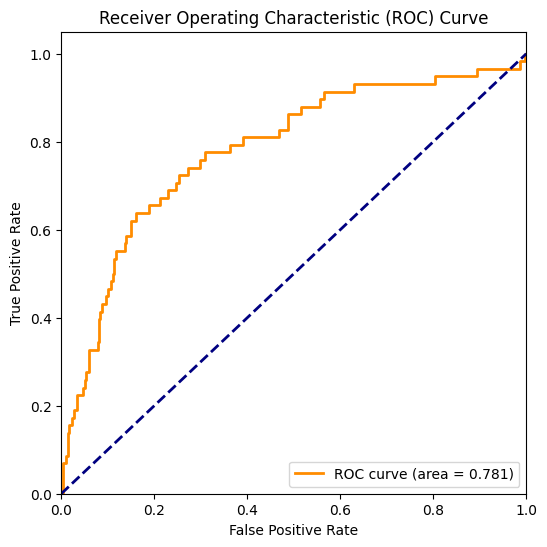

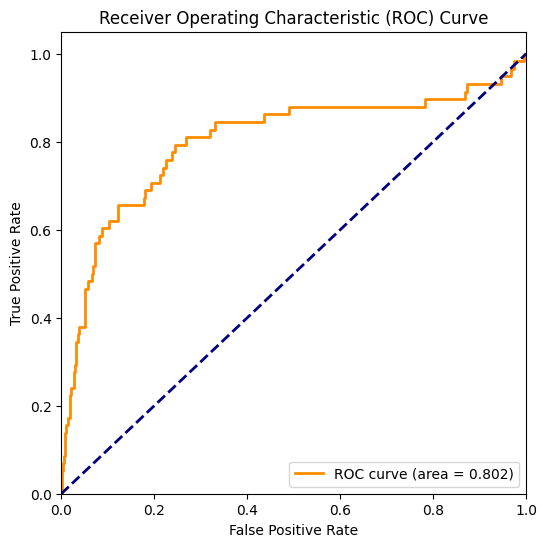

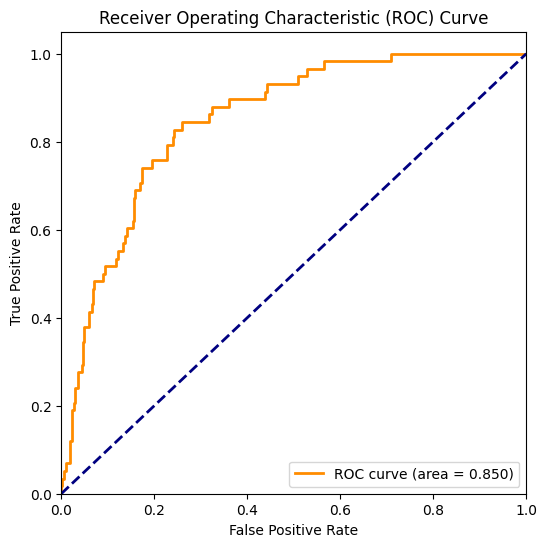

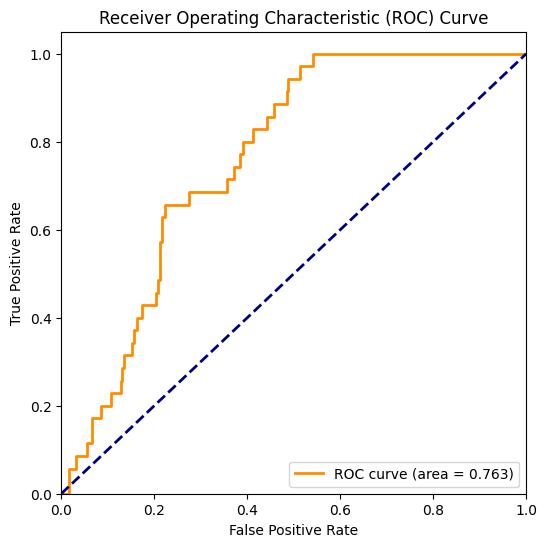

In [3]:
from sklearn.metrics import roc_auc_score, roc_curve


def plot_roc_curve(predictions, filename):
    roc_auc = roc_auc_score(predictions["targets"], predictions["predictions"])
    print(f"ROC AUC Score: {roc_auc}")
    fpr, tpr, _ = roc_curve(predictions["targets"], predictions["predictions"])

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")

    plt.savefig(filename, format="pdf", bbox_inches="tight")

plot_roc_curve(pd.read_csv('./predictions.lr.csv'), "roc_curve.lr.pdf")
plot_roc_curve(pd.read_csv('./predictions.hgb.csv'), "roc_curve.hgb.pdf")
plot_roc_curve(pd.read_csv('./predictions.csv'), "roc_curve.validate.pdf")
plot_roc_curve(pd.read_csv('./predictions.20250829.csv'), "roc_curve.20250829.pdf")

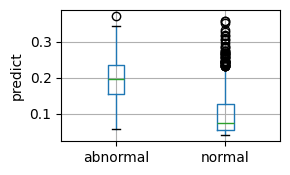

In [4]:
boxplot = predict_result.boxplot(column=["predictions"], by="targets", figsize=(3, 2))

plt.suptitle('')
plt.title('')
plt.xlabel('')
plt.ylabel('predict')
plt.tight_layout()
plt.show()

/data/li-ming-hong/miniconda3/envs/ivf/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


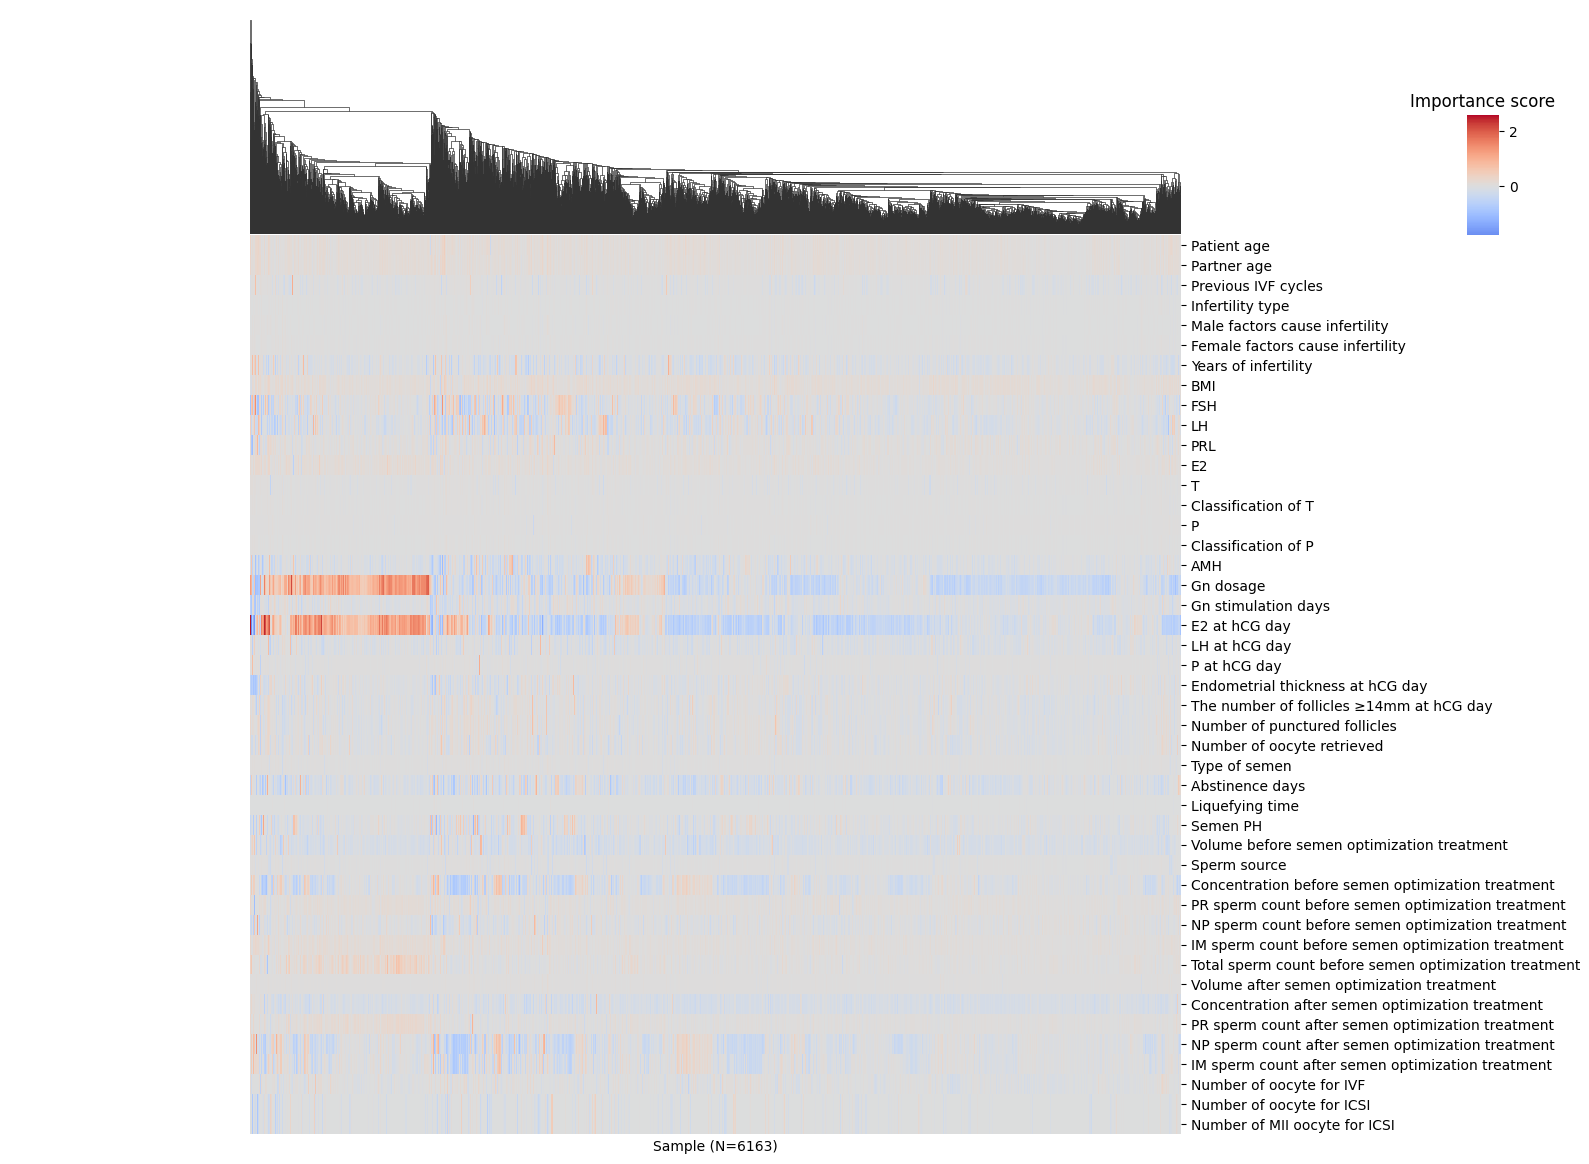

In [5]:
_df = interpret_result.drop(columns=["Normal fertilization"]).copy()
_df = _df.map(lambda x: np.sign(x) * np.log1p(np.abs(x)))
_df = _df.rename(columns={
    "Body Mass Index (BMI)": "BMI",
    "Follicle Stimulating Hormone (FSH)": "FSH",
    "Luteinizing hormone (LH)": "LH",
    "Prolactin (PRL)": "PRL",
    "Estradiol (E2)": "E2",
    "Testosterone (T)": "T",
    "Progesterone (P)": "P",
    "anti-Müllerian hormone (AMH)": "AMH",
    "Gonadotropin (Gn) dosage": "Gn dosage",
    "PR (Progressive motility) sperm count before semen optimization treatment": "PR sperm count before semen optimization treatment",
    "NP (Non-progressive motility) sperm count before semen optimization treatment": "NP sperm count before semen optimization treatment",
    "IM (Immotile) sperm count before semen optimization treatment": "IM sperm count before semen optimization treatment",
    "Total sperm count before semen optimization treatment (x10^6)": "Total sperm count before semen optimization treatment",
})

g = sns.clustermap(
    data=_df.T.fillna(0), cmap='coolwarm', center=0, figsize=(16, 12), row_cluster=False,
    cbar_pos=(0.92, 0.8, 0.02, 0.1),
    # cbar_kws={'label': 'Importance score'},
    # col_colors=_colors,
    # yticklabels=False
)
g.ax_cbar.set_title('Importance score')
g.ax_heatmap.set_xlabel('Sample (N={})'.format(_df.shape[0]))
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xticks([])

plt.savefig("{}.pdf".format("interpret_result"), format="pdf", bbox_inches="tight")
plt.show()

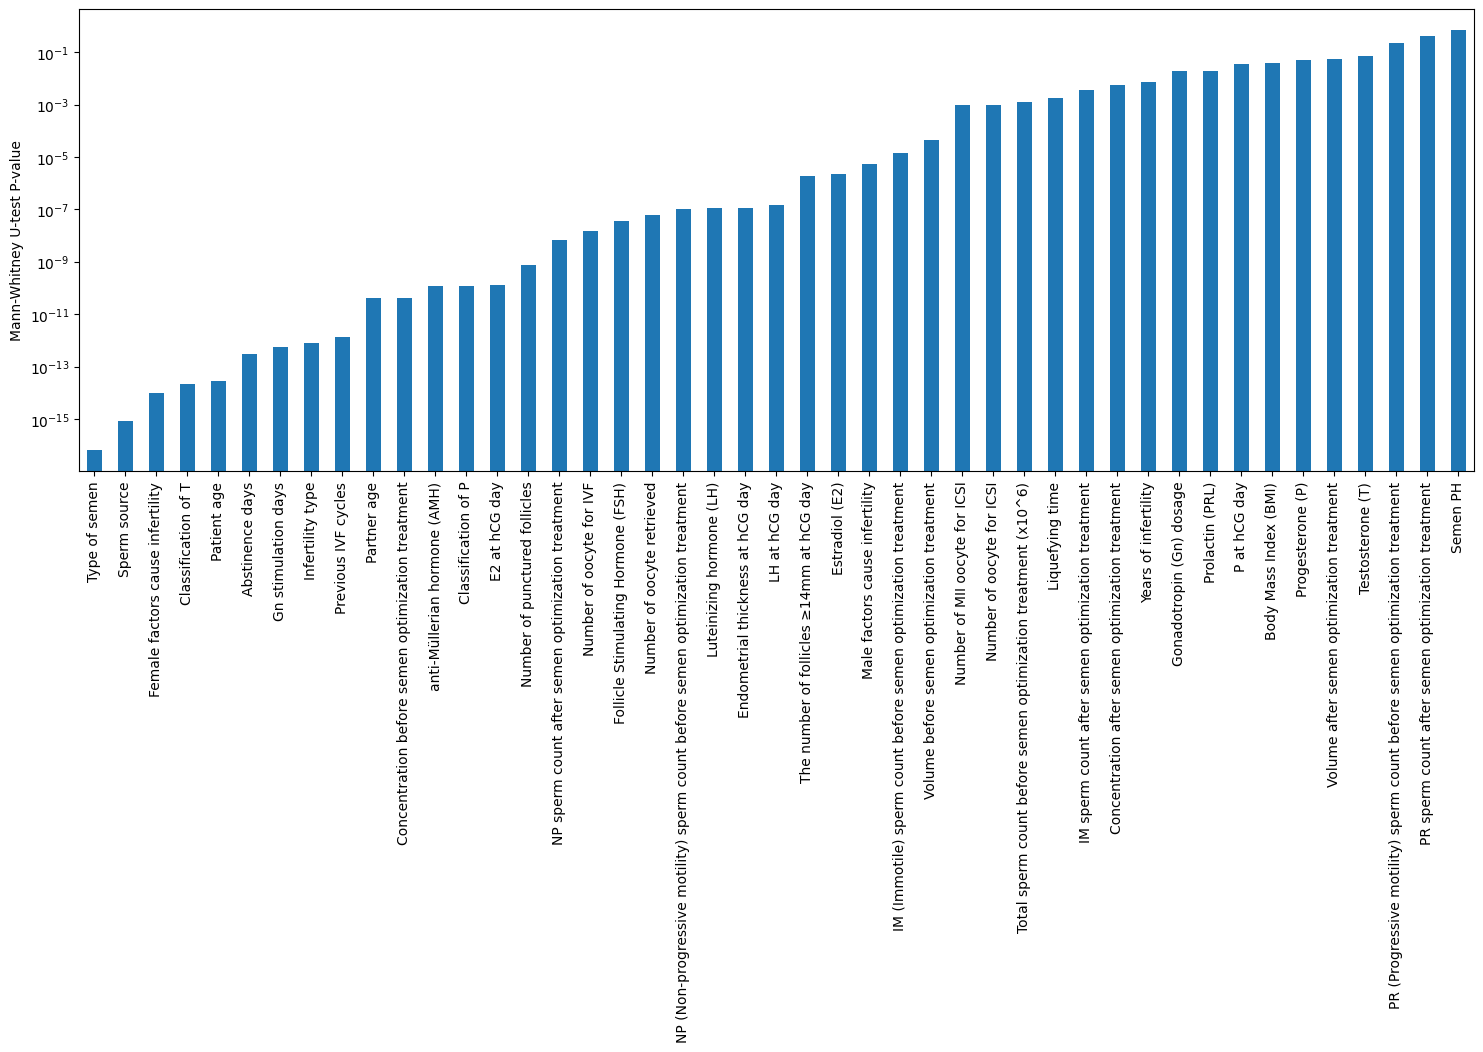

In [6]:
_normal = interpret_result[interpret_result["Normal fertilization"] == 'normal'].drop(columns=["Normal fertilization"])
_abnormal = interpret_result[interpret_result["Normal fertilization"] == 'abnormal'].drop(columns=["Normal fertilization"])

test_result = {}
for column in _normal.columns:
    _normal_clean = _normal[column][~np.isnan(_normal[column])]
    _abnormal_clean = _abnormal[column][~np.isnan(_abnormal[column])]
    u_stat, u_pvalue = mannwhitneyu(_normal_clean, _abnormal_clean, alternative='two-sided')
    
    test_result[column] = [u_pvalue]
test_result = pd.DataFrame(test_result)

ax = test_result.T.sort_values(by=0).plot(kind='bar', figsize=(18, 6), logy=True, legend=False)
plt.ylabel("Mann-Whitney U-test P-value")
plt.show()


In [7]:
# _tmp = test_result.T.sort_values(by=0)
# _tmp = _tmp[_tmp[0] < 0.01]
# display(_tmp.index)
# for _index in _tmp.index:
#     fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
#     interpret_result.boxplot(column=[_index], by="Normal fertilization", ax=axes[0])
#     data.boxplot(column=[_index], by="Normal fertilization", ax=axes[1])

#     plt.suptitle('')
#     axes[0].set_title('')
#     axes[0].set_xlabel('')
#     axes[0].set_ylabel("Importance score of {}".format(_index))
#     axes[1].set_title('')
#     axes[1].set_xlabel('')
#     axes[1].set_ylabel("Raw count of {}".format(_index))
#     plt.tight_layout()
#     plt.show()

In [8]:
suggest_all = {}
for i in range(1, 15):
    suggest_all[i] = pd.read_csv('suggest_{}.csv'.format(i), index_col=0)

,before,1,2,3,4,5,6,7,8,9,10,11,12,13,14
19,0.078314,0.077247,0.062763,0.057051,0.050460,0.050636,0.051082,0.050520,0.050261,0.048994,0.048986,0.047532,0.047360,0.047360,0.047347
22,0.148305,0.146636,0.144878,0.095305,0.077642,0.077372,0.077004,0.044263,0.076164,0.070980,0.070969,0.042736,0.042718,0.042718,0.042682
68,0.097499,0.083308,0.083422,0.078841,0.078659,0.076940,0.073644,0.071501,0.065088,0.064872,0.064281,0.063989,0.056323,0.056323,0.056293
83,0.233885,0.202011,0.200676,0.148456,0.208081,0.202124,0.196109,0.119931,0.118363,0.091745,0.088599,0.088442,0.087972,0.087976,0.087799
93,0.081342,0.076094,0.076011,0.076515,0.071944,0.071222,0.070330,0.069105,0.068533,0.066600,0.065961,0.065673,0.065705,0.065706,0.065578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6122,0.198880,0.183256,0.164047,0.157007,0.157049,0.156541,0.152639,0.162942,0.100802,0.098134,0.098122,0.092067,0.092067,0.086680,0.084135
6143,0.250608,0.207974,0.206084,0.167942,0.167942,0.162026,0.046133,0.046132,0.042263,0.042712,0.042711,0.042711,0.043290,0.043292,0.043288
6148,0.298307,0.287332,0.197393,0.216405,0.039860,0.039864,0.039840,0.039886,0.057904,0.057949,0.057223,0.039873,0.039860,0.039862,0.042856
6155,0.177462,0.040846,0.040770,0.040127,0.040135,0.040090,0.039957,0.040069,0.040061,0.040108,0.039901,0.040195,0.040320,0.040237,0.040292


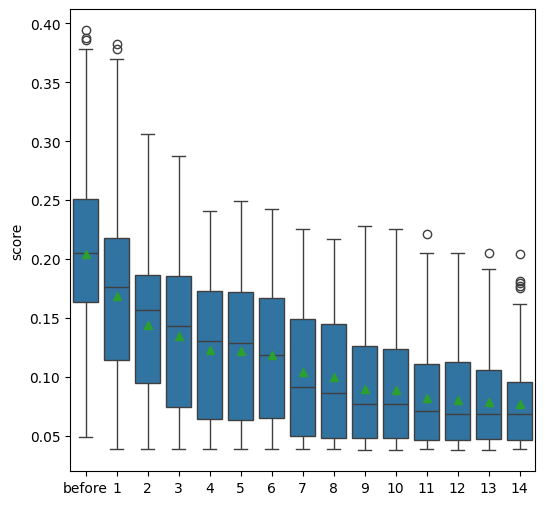

In [9]:
score_df = pd.DataFrame()
for i in range(1, 15):
    _suggest = suggest_all[i].loc["score"]
    _suggest = _suggest.apply(ast.literal_eval)
    _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before_{}".format(i), i])
    score_df = pd.concat([score_df, _suggest], axis=1)
score_df = score_df[["before_1"] + [i for i in range(1, 15)]]
score_df.columns = ["before"] + [i for i in range(1, 15)]
display(score_df)

plt.figure(figsize=(6, 6))
_melt_suggest = pd.melt(score_df, var_name='type', value_name='value')
ax = sns.boxplot(x='type', y='value', data=_melt_suggest, showmeans=True)

# pairs=[("before", 1), (1, 2), (2, 4), (4, 7), (7, 14)]
# annotator = Annotator(ax, pairs, data=_melt_suggest, x="type", y="value")
# annotator.configure(test='Wilcoxon', text_format='star')
# annotator.apply_and_annotate()

ax.set_xlabel("")
ax.set_ylabel("score")
plt.savefig("suggest_score_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

suggest = suggest_all[7]

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

before vs. after: Wilcoxon test (paired samples), P_val:3.887e-10 Stat=1.147e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

before vs. after: Wilcoxon test (paired samples), P_val:1.342e-05 Stat=1.443e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

before vs. after: Wilcoxon test (paired samples), P_val:4.299e-10 Stat=6.708e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <=

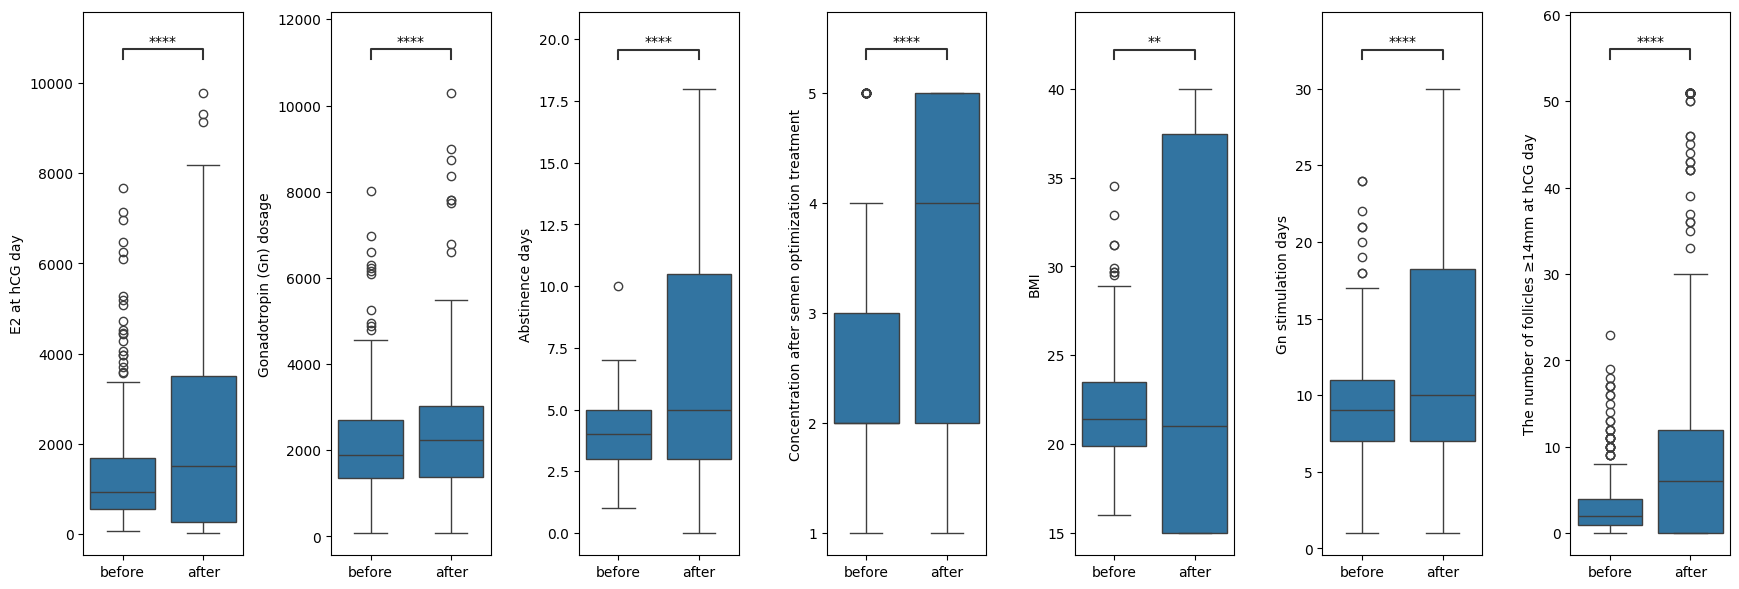

In [10]:
plot_index = suggest.index.drop("score")
num_plots = len(plot_index)
fig, axes = plt.subplots(1, 7, figsize=(2.5 * num_plots, 6))
for plot_idx, index in enumerate(plot_index):
    _suggest = suggest.loc[index]
    _suggest = _suggest[~_suggest.str.contains("nan")]
    _suggest = _suggest.apply(ast.literal_eval)
    _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before", "after"])
    _suggest = pd.melt(_suggest, var_name='type', value_name='value')

    ax = axes[plot_idx]
    sns.boxplot(x='type', y='value', data=_suggest, ax=ax)

    pairs=[("before", "after")]
    annotator = Annotator(ax, pairs, data=_suggest, x="type", y="value")
    annotator.configure(test='Wilcoxon', text_format='star')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(index)

plt.tight_layout()
plt.savefig("suggest_feature_diff_7.pdf", format="pdf", bbox_inches="tight")
plt.show()

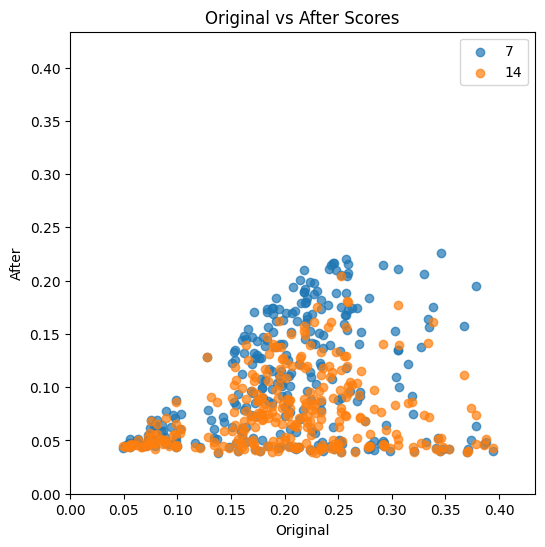

In [11]:
suggest_7 = suggest_all[7].loc["score"]
suggest_7 = suggest_7[~suggest_7.str.contains("nan")]
suggest_7 = suggest_7.apply(ast.literal_eval)
df_7 = pd.DataFrame(suggest_7.tolist(), index=suggest_7.index, columns=["before", "after"])

suggest_14 = suggest_all[14].loc["score"]
suggest_14 = suggest_14[~suggest_14.str.contains("nan")]
suggest_14 = suggest_14.apply(ast.literal_eval)
df_14 = pd.DataFrame(suggest_14.tolist(), index=suggest_14.index, columns=["before", "after"])

plt.figure(figsize=(6, 6))

plt.scatter(df_7['before'], df_7['after'], label='7', alpha=0.7)
plt.scatter(df_14['before'], df_14['after'], label='14', alpha=0.7)

max_val_7 = df_7.max().max()
max_val_14 = df_14.max().max()
max_overall_val = max(max_val_7, max_val_14)

plt.xlim(0, max_overall_val * 1.1)
plt.ylim(0, max_overall_val * 1.1)

plt.xlabel('Original')
plt.ylabel('After')
plt.title('Original vs After Scores')
plt.legend()
plt.savefig("suggest_score_diff.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
changed_value = pd.DataFrame(
    [
        [int(index), value[0] - value[1]]
        for index, value in suggest.loc["score"].apply(ast.literal_eval).items()
    ],
    columns=["index", "diff"],
)
cut_value = changed_value["diff"].quantile(0.05)

ivf_success_sample = data[data["Normal fertilization"] == "normal"].copy()
suggest_failed_sample = data[data["ID"].isin(changed_value[changed_value["diff"] <= cut_value]["index"].to_list())].copy()
suggest_success_sample = data[data["ID"].isin(changed_value[changed_value["diff"] > cut_value]["index"].to_list())].copy()

ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:1.059e-01 U_stat=3.342e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:3.061e-01 U_stat=1.752e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:1.442e-01 U_stat=3.445e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:6.531e-01 U_stat=1.934e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:3.703e-02 U_stat=3.323e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:1.477e-01 U_stat=1.634e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:9.486e-02 U_stat=5.350e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:5.584e-02 U_stat=1.555e+03
ivf success vs. suggest failed: Mann-Whitney-Wilcoxon test two-sided, P_val:1.149e-01 U_stat=5.299e+04
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon

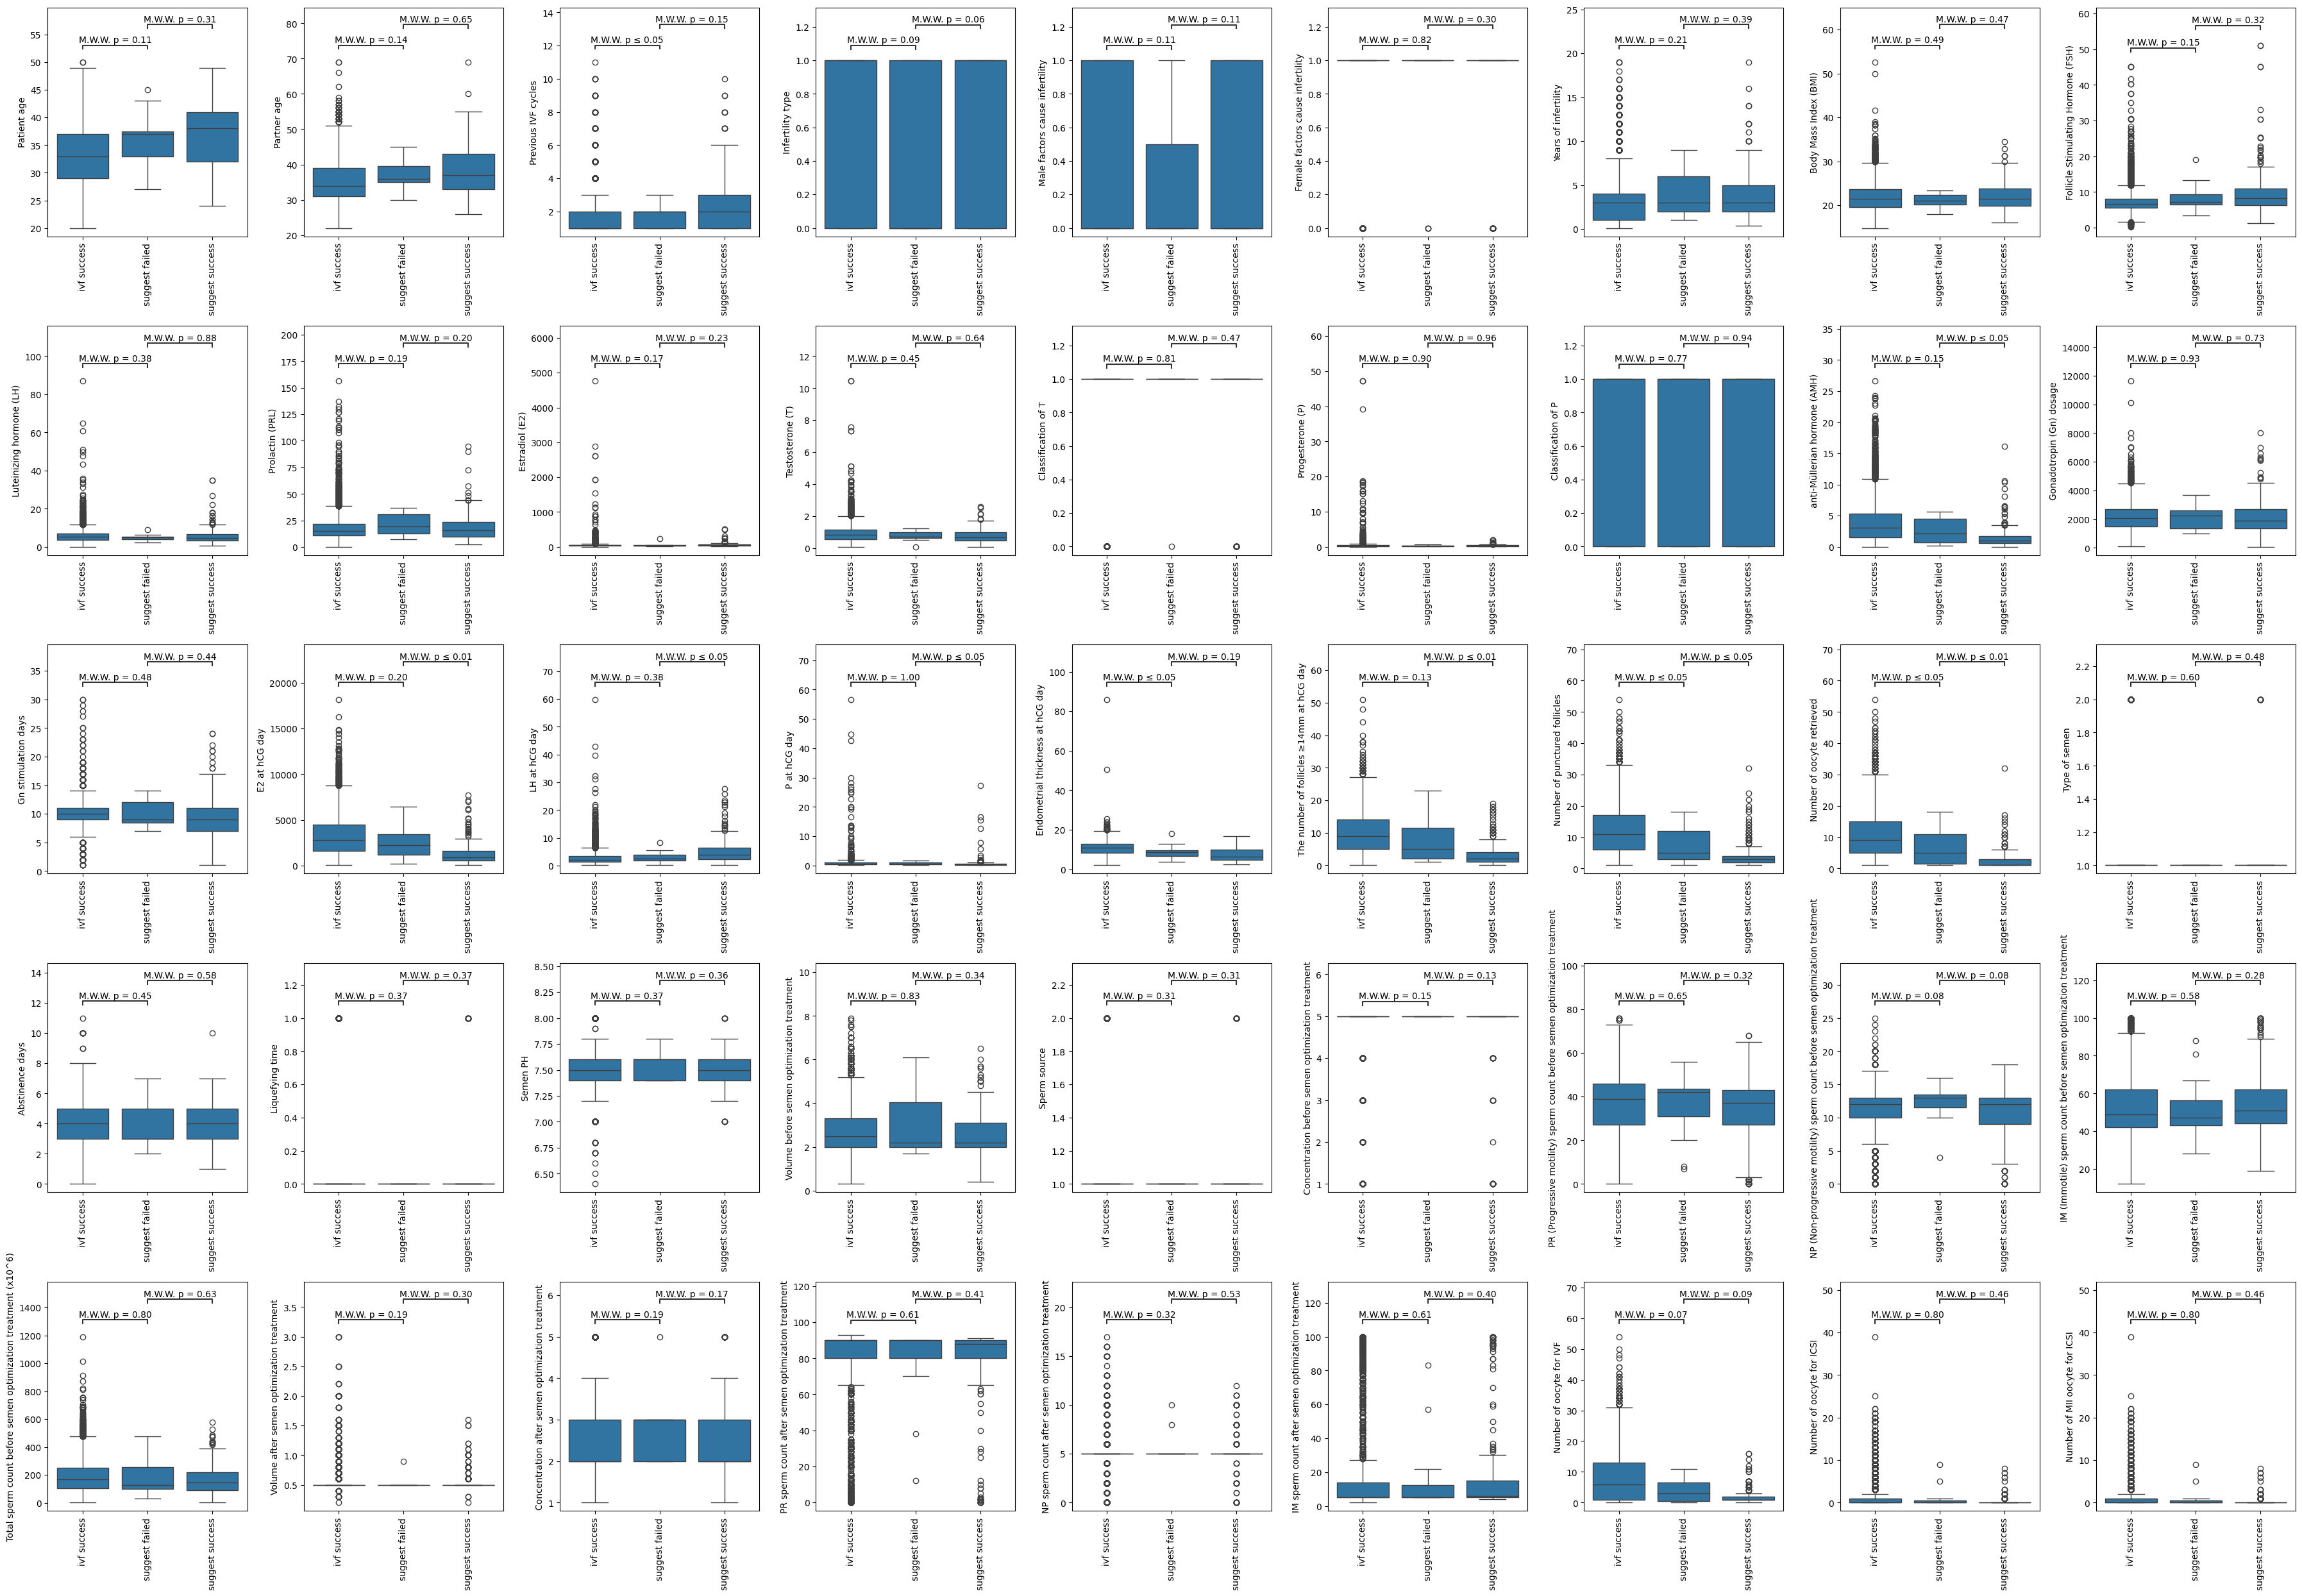

In [13]:
fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(9 * 4, 5 * 5))
axes = axes.flatten()

columns_to_plot = ivf_success_sample.drop(columns=['ID', 'Normal fertilization']).columns
# for index in ["E2 at hCG day", "Gonadotropin (Gn) dosage", "Abstinence days", "Concentration after semen optimization treatment"]:
for i, feature in enumerate(columns_to_plot):
    _ivf_success_data = ivf_success_sample[feature].copy()
    _ivf_success_data.dropna(inplace=True)
    _suggest_failed_sample = suggest_failed_sample[feature].copy()
    _suggest_failed_sample.dropna(inplace=True)
    _suggest_success_sample = suggest_success_sample[feature].copy()
    _suggest_success_sample.dropna(inplace=True)

    _ivf_success_data = _ivf_success_data.to_frame()
    _ivf_success_data["type"] = "ivf success"
    _suggest_failed_sample = _suggest_failed_sample.to_frame()
    _suggest_failed_sample["type"] = "suggest failed"
    _suggest_success_sample = _suggest_success_sample.to_frame()
    _suggest_success_sample["type"] = "suggest success"

    _df = pd.concat([_ivf_success_data, _suggest_failed_sample, _suggest_success_sample], axis=0)
    _df.columns = ["value", "type"]

    ax = axes[i]
    sns.boxplot(x='type', y='value', data=_df, ax=ax)

    pairs=[("ivf success", "suggest failed"), ("suggest failed", "suggest success")]
    annotator = Annotator(ax, pairs, data=_df, x="type", y="value")
    annotator.configure(test='Mann-Whitney', text_format='simple')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=90)

for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:1.780e-01 U_stat=2.435e+03
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:8.485e-01 U_stat=2.108e+03
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:5.841e-01 U_stat=2.082e+03
suggest failed vs. suggest success: Mann-Whitney-Wilcoxon test two-sided, P_val:7.153e-02 U_stat=2.652e+03


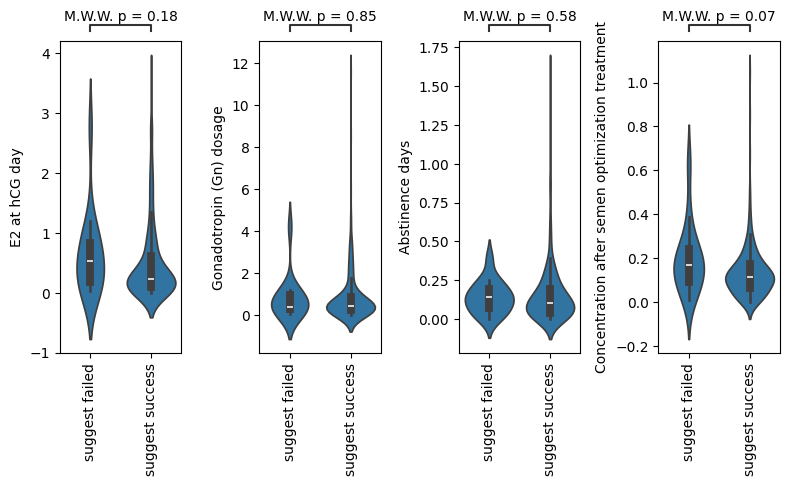

In [14]:
# ivf_success_interpret = interpret_result[interpret_result["Normal fertilization"] == "normal"].copy()
suggest_failed_interpret = interpret_result.loc[data["ID"].isin(changed_value[changed_value["diff"] <= cut_value]["index"].to_list())].copy()
suggest_success_interpret = interpret_result.loc[data["ID"].isin(changed_value[changed_value["diff"] > cut_value]["index"].to_list())].copy()


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(4 * 2, 1 * 5))
axes = axes.flatten()

columns_to_plot = ["E2 at hCG day", "Gonadotropin (Gn) dosage", "Abstinence days", "Concentration after semen optimization treatment"]
for i, feature in enumerate(columns_to_plot):
    # _ivf_success_interpret = ivf_success_interpret[feature].copy()
    # _ivf_success_interpret.dropna(inplace=True)
    _suggest_failed_sample = suggest_failed_interpret[feature].copy()
    _suggest_failed_sample.dropna(inplace=True)
    _suggest_success_sample = suggest_success_interpret[feature].copy()
    _suggest_success_sample.dropna(inplace=True)

    # _ivf_success_interpret = _ivf_success_interpret.to_frame()
    # _ivf_success_interpret["type"] = "ivf success"
    _suggest_failed_sample = _suggest_failed_sample.to_frame()
    _suggest_failed_sample["type"] = "suggest failed"
    _suggest_success_sample = _suggest_success_sample.to_frame()
    _suggest_success_sample["type"] = "suggest success"

    # _df = pd.concat([_ivf_success_interpret, _suggest_failed_sample, _suggest_success_sample], axis=0)
    _df = pd.concat([_suggest_failed_sample, _suggest_success_sample], axis=0)
    _df.columns = ["value", "type"]
    _df["value"] = _df["value"].abs()

    ax = axes[i]
    sns.violinplot(x='type', y='value', data=_df, ax=ax)

    # pairs=[("ivf success", "suggest failed"), ("suggest failed", "suggest success")]
    pairs=[("suggest failed", "suggest success")]
    annotator = Annotator(ax, pairs, data=_df, x="type", y="value")
    annotator.configure(test='Mann-Whitney', text_format='simple', loc='outside')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=90)

for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()